# Abdomen Lift Detection

Companion to `Joint_Kinematics_Analysis.ipynb`. Detects discrete abdomen-lift events (~30 ms) from the egocentric Abd_tip Z signal, characterizes their relationship to locomotion speed and gait phase, and optionally overlays them onto UMAP embeddings.

**Prerequisites:** run `Joint_Kinematics_Analysis.ipynb` cells 1–14 first (or at minimum export `df_valid` as a pickle). Set `H5_PATH` and `OUTPUT_DIR` in the Setup cell below.

In [1]:
### Setup — paths, imports
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from scipy import signal
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.signal import find_peaks, butter, filtfilt
from scipy.stats import iqr as scipy_iqr
from itertools import groupby as _groupby
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Add 3d_tracking_dataset repo root so utils can be imported
_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

# ── Edit these paths ──────────────────────────────────────────────────────────
H5_PATH    = Path("/home/user/3D_tracking_paper/IK_outputs/walking_videos/free_walking/Data_analysis/analysis/ik_output_combined_v1_free_walking.h5")
OUTPUT_DIR = Path('/home/user/3D_tracking_paper/output/free_walking')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FPS           = 800
LEGS          = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
REFERENCE_LEG = 'T1_left'
HEADING_BODIES = ['thorax']
SCALE         = 10.0   # model units → mm


## Build df_valid from HDF5

Builds the per-frame DataFrame from the STAC IK output HDF5. Set `H5_PATH` in the Setup cell above, then run the next cell.

**Columns produced:**

| Column | Description |
|---|---|
| `bout_id` | HDF5 group key |
| `fly_id` | first token of `bout_id` split on `_` (edit `_parse_fly_id` if needed) |
| `frame` | 0-based frame index within bout |
| `forward_speed` | thorax XY displacement × FPS (mm/s) |
| `T1_left_phase` | linear phase in [−π, π] per T1L stride cycle; NaN outside complete cycles |
| `n_legs_stance` | legs in stance (0–6) per frame |

**Site indices** (fruitfly_v1, verified from `fruitfly_v1_free.xml`):
`T1L=18, T1R=25, T2L=31, T2R=37, T3L=43, T3R=49` in `xpos_egocentric[:,idx,:]`

In [2]:
### Build df_valid — pipeline functions (mirrors Joint_Kinematics_Analysis)

# ── Data loading ──────────────────────────────────────────────────────────────
def load_ik_bouts(h5_path):
    d = ioh5.load(h5_path)
    bout_keys    = sorted(k for k in d if k.startswith('bout_'))
    fly_ids      = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique flies")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths

_LEG_SHORT = {
    'T1_left':  'T1L', 'T1_right': 'T1R',
    'T2_left':  'T2L', 'T2_right': 'T2R',
    'T3_left':  'T3L', 'T3_right': 'T3R',
}

def find_leg_tip_site_indices(site_names, legs):
    indices = {}
    for leg in legs:
        short = _LEG_SHORT.get(leg, leg)
        patterns = [f"{short}_TaTip", f"{leg}_TaTip", f"claw_{leg}", f"{leg}_claw"]
        match = None
        for p in patterns:
            match = next((i for i, n in enumerate(site_names) if p in n), None)
            if match is not None:
                break
        indices[leg] = match
        if match is None:
            print(f"Warning: no tip site for {leg}")
    return indices

def bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list,
                       names_xpos, heading_bodies,
                       egocentric_site_names, leg_tip_site_indices):
    frames = []
    for bout_idx, (key, fly_id) in enumerate(zip(bout_keys, fly_ids)):
        b    = bout_dict[key]
        xpos = np.array(b['xpos'])
        T    = xpos.shape[0]
        row  = {
            'frame':    np.arange(T),
            'bout_idx': np.full(T, bout_idx, dtype=np.int32),
            'bout_id':  np.full(T, key, dtype=object),
            'fly_id':   np.full(T, fly_id, dtype=object),
        }
        if 'qpos' in b:
            qpos = np.array(b['qpos'])
            for leg, joint, idx in joint_list:
                row[f"{leg}_{joint}"] = qpos[:, idx]
        for body in heading_bodies:
            if body in names_xpos:
                bidx = names_xpos.index(body)
                row[f"{body}_x"] = xpos[:, bidx, 0]
                row[f"{body}_y"] = xpos[:, bidx, 1]
                row[f"{body}_z"] = xpos[:, bidx, 2]
        if 'xpos_egocentric' in b:
            xpos_ego = np.array(b['xpos_egocentric'])
            for leg, site_idx in leg_tip_site_indices.items():
                if site_idx is not None and site_idx < xpos_ego.shape[1]:
                    row[f"{leg}_tip_x_ego"] = xpos_ego[:, site_idx, 0]
                    row[f"{leg}_tip_y_ego"] = xpos_ego[:, site_idx, 1]
                    row[f"{leg}_tip_z_ego"] = xpos_ego[:, site_idx, 2]
        _CLAW_NAMES = {
            'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right',
            'T2_left': 'claw_T2_left', 'T2_right': 'claw_T2_right',
            'T3_left': 'claw_T3_left', 'T3_right': 'claw_T3_right',
        }
        for leg, cname in _CLAW_NAMES.items():
            if cname in names_xpos:
                ci = names_xpos.index(cname)
                row[f"{leg}_tip_x_world"] = xpos[:, ci, 0]
                row[f"{leg}_tip_y_world"] = xpos[:, ci, 1]
                row[f"{leg}_tip_z_world"] = xpos[:, ci, 2]
        frames.append(pd.DataFrame(row))
    df = pd.concat(frames, ignore_index=True)
    print(f"Built DataFrame: {len(df):,} frames, {len(df.columns)} columns")
    return df

# ── Preprocessing ─────────────────────────────────────────────────────────────
def _gaussian_smooth(arr, sigma=4):
    mask = np.isnan(arr)
    out  = gaussian_filter1d(np.where(mask, 0., arr), sigma)
    cnt  = gaussian_filter1d((~mask).astype(float), sigma)
    out[cnt > 0] /= cnt[cnt > 0]
    out[mask]     = np.nan
    return out

def swing_onsets_from_stance(series):
    ss = series.values.astype(int)
    return np.where(np.diff(ss, prepend=ss[0]) == -1)[0]

def compute_swing_stance_tip_speed(df, legs, fps=800, thresh_frac=0.20):
    df = df.copy()
    for leg in legs:
        xcol, ycol, zcol = f"{leg}_tip_x_world", f"{leg}_tip_y_world", f"{leg}_tip_z_world"
        if zcol not in df.columns:
            continue
        ss = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx = grp.index
            n   = len(grp)
            if n < 5:
                continue
            def _vel(col):
                v = grp[col].values.astype(float) if col in grp.columns else np.zeros(n)
                return np.gradient(v) * fps * 10
            spd = np.sqrt(_vel(xcol)**2 + _vel(ycol)**2 + _vel(zcol)**2)
            spd = _gaussian_smooth(spd, sigma=4)
            thr = thresh_frac * np.nanmax(spd)
            ss[idx] = (spd <= thr).astype(float)
        valid = ~np.isnan(ss)
        df.loc[valid, f"{leg}_swing_stance"] = ss[valid].astype(int)
    return df

def compute_n_legs_stance(df, legs):
    df = df.copy()
    cols = [f"{leg}_swing_stance" for leg in legs if f"{leg}_swing_stance" in df.columns]
    if cols:
        df['n_legs_stance'] = df[cols].sum(axis=1)
    return df

def compute_phases_from_swing(df, legs):
    df = df.copy()
    for leg in legs:
        ss_col = f"{leg}_swing_stance"
        if ss_col not in df.columns:
            continue
        phase_arr = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx    = grp.index
            onsets = swing_onsets_from_stance(grp[ss_col])
            if len(onsets) < 2:
                continue
            phase = np.full(len(grp), np.nan)
            for i in range(len(onsets) - 1):
                t0, t1 = onsets[i], onsets[i + 1]
                phase[t0:t1] = np.linspace(-np.pi, np.pi, t1 - t0, endpoint=False)
            phase_arr[idx] = phase
        df[f"{leg}_phase"] = phase_arr
    return df

def compute_heading_and_velocity(df, fps=800, body='thorax', smooth_sigma=2):
    df = df.copy()
    x_col, y_col = f"{body}_x", f"{body}_y"
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Warning: position columns not found for {body}")
        return df
    heading_arr   = np.full(len(df), np.nan)
    speed_arr     = np.full(len(df), np.nan)
    turn_rate_arr = np.full(len(df), np.nan)
    for bout_id, grp in df.groupby('bout_id'):
        idx = grp.index
        x   = gaussian_filter1d(grp[x_col].values.astype(float), sigma=smooth_sigma)
        y   = gaussian_filter1d(grp[y_col].values.astype(float), sigma=smooth_sigma)
        dx  = np.gradient(x) * fps
        dy  = np.gradient(y) * fps
        heading   = np.arctan2(dy, dx)
        heading_u = np.unwrap(heading)
        heading_s = gaussian_filter1d(heading_u, sigma=smooth_sigma)
        heading_s = (heading_s + np.pi) % (2 * np.pi) - np.pi
        heading_arr[idx]   = heading_s
        speed_arr[idx]     = np.sqrt(dx**2 + dy**2) * 10   # mm/s
        turn_rate_arr[idx] = np.gradient(heading_s) * fps
    df['heading']       = heading_arr
    df['forward_speed'] = speed_arr
    df['turning_rate']  = turn_rate_arr
    return df

def compute_step_cycle_speed(df, fps=800, ref_leg='T1_left'):
    df      = df.copy()
    ss_col  = f"{ref_leg}_swing_stance"
    spd_col = 'forward_speed'
    sc_id   = np.full(len(df), np.nan)
    sc_spd  = np.full(len(df), np.nan)
    if ss_col not in df.columns:
        df['step_cycle_id']         = sc_id
        df['step_cycle_mean_speed'] = sc_spd
        return df
    for bout_id, grp in df.groupby('bout_id', sort=False):
        idx    = grp.index
        onsets = swing_onsets_from_stance(grp[ss_col])
        if len(onsets) < 2:
            continue
        spd = grp[spd_col].values.astype(float) if spd_col in grp.columns               else np.full(len(grp), np.nan)
        for k in range(len(onsets) - 1):
            t0, t1 = onsets[k], onsets[k + 1]
            sc_id[idx[t0:t1]]  = k
            sc_spd[idx[t0:t1]] = np.nanmean(spd[t0:t1])
    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    return df

# ── Build df_valid ────────────────────────────────────────────────────────────
bout_dict, bout_keys, fly_ids, clip_lengths = load_ik_bouts(H5_PATH)
names_qpos            = list(bout_dict['info']['names_qpos'])
names_xpos            = list(bout_dict['info']['names_xpos'])
egocentric_site_names = list(bout_dict['info']['site_names_egocentric'])

leg_tip_site_indices = find_leg_tip_site_indices(egocentric_site_names, LEGS)
print(f"Leg tip site indices: {leg_tip_site_indices}")

# No joint angles needed — pass empty joint_list
df = bouts_to_dataframe(
    bout_dict, bout_keys, fly_ids, joint_list=[],
    names_xpos=names_xpos,
    heading_bodies=HEADING_BODIES,
    egocentric_site_names=egocentric_site_names,
    leg_tip_site_indices=leg_tip_site_indices,
)

df = compute_swing_stance_tip_speed(df, LEGS, fps=FPS)
df = compute_n_legs_stance(df, LEGS)
df = compute_phases_from_swing(df, LEGS)
df = compute_heading_and_velocity(df, fps=FPS, body=HEADING_BODIES[0])
df = compute_step_cycle_speed(df, fps=FPS, ref_leg=REFERENCE_LEG)

df_valid = df.copy()
print(f"\ndf_valid: {len(df_valid):,} rows | "
      f"{df_valid['bout_id'].nunique()} bouts | "
      f"{df_valid['fly_id'].nunique()} flies")
print(f"  forward_speed (mm/s):  {df_valid['forward_speed'].mean():.1f} ± "
      f"{df_valid['forward_speed'].std():.1f}")
print(f"  n_legs_stance:         {df_valid['n_legs_stance'].mean():.2f} mean")
print(f"  T1_left_phase valid:   "
      f"{df_valid['T1_left_phase'].notna().mean()*100:.1f}% of frames")
print(f"  step_cycle_mean_speed: "
      f"{df_valid['step_cycle_mean_speed'].notna().mean()*100:.1f}% of frames")


Loaded 198 bouts | 7 unique flies
Frames/bout: min=151, max=1271, total=78,633
Leg tip site indices: {'T1_left': 18, 'T1_right': 25, 'T2_left': 31, 'T2_right': 37, 'T3_left': 43, 'T3_right': 49}
Built DataFrame: 78,633 frames, 43 columns

df_valid: 78,633 rows | 198 bouts | 7 flies
  forward_speed (mm/s):  18.8 ± 10.2
  n_legs_stance:         3.70 mean
  T1_left_phase valid:   76.4% of frames
  step_cycle_mean_speed: 76.4% of frames


In [ ]:
fFFFFFFFDDDDDDDSSSSSSSSSDDDDDDDDDDDSSSmetssssse### Cell I1 — Add abdomen signals to df_valid

df_valid['abd_tip_ego_z']  = np.nan
df_valid['abd_a4_ego_z']   = np.nan
df_valid['abd_relative_z'] = np.nan   # Abd_tip_ego_z - Abd_a4_ego_z (tail span)

H5_PATH_STR = str(H5_PATH)

with h5py.File(H5_PATH_STR, 'r') as f:
    for bid in df_valid['bout_id'].unique():
        idx    = df_valid[df_valid['bout_id'] == bid].index
        frames = df_valid.loc[idx, 'frame'].values   # 0-based frame index within bout

        xego = np.array(f[bid]['xpos_egocentric'][:])   # (T, 50, 3)

        df_valid.loc[idx, 'abd_tip_ego_z'] = xego[frames, 11, 2]
        df_valid.loc[idx, 'abd_a4_ego_z']  = xego[frames, 10, 2]
        df_valid.loc[idx, 'abd_relative_z'] = xego[frames, 11, 2] - xego[frames, 10, 2]

df_valid['abd_tip_ego_z_mm']  = df_valid['abd_tip_ego_z']  * 10.0
df_valid['abd_a4_ego_z_mm']   = df_valid['abd_a4_ego_z']   * 10.0
df_valid['abd_relative_z_mm'] = df_valid['abd_relative_z'] * 10.0

print(f"Abd_tip_ego_z_mm:  mean={df_valid['abd_tip_ego_z_mm'].mean():.2f} "
      f"std={df_valid['abd_tip_ego_z_mm'].std():.2f} mm")
print(f"Abd_relative_z_mm: mean={df_valid['abd_relative_z_mm'].mean():.2f} "
      f"std={df_valid['abd_relative_z_mm'].std():.2f} mm")

Abd_tip_ego_z_mm:  mean=-0.63 std=0.08 mm
Abd_relative_z_mm: mean=-0.73 std=0.06 mm


In [4]:
### Cell I2 — Per-bout detrended abdomen signal

BASELINE_FRAMES_ABD = int(0.500 * FPS)   # 400 frames

df_valid['abd_tip_detrended_mm'] = np.nan

for bid, grp in df_valid.groupby('bout_id', sort=False):
    idx  = grp.index
    if len(idx) < 30:
        continue
    z_mm = grp['abd_tip_ego_z_mm'].values
    if np.all(np.isnan(z_mm)):
        continue
    z_smooth = gaussian_filter1d(z_mm, sigma=3)   # ~3.75 ms smoothing
    baseline = uniform_filter1d(z_smooth, size=BASELINE_FRAMES_ABD, mode='nearest')
    df_valid.loc[idx, 'abd_tip_detrended_mm'] = z_smooth - baseline

print("Abd detrended signal ready.")
print(f"  std = {df_valid['abd_tip_detrended_mm'].std():.4f} mm")

Abd detrended signal ready.
  std = 0.0489 mm


In [5]:
### Cell I3 — Lift event detector

LIFT_THRESHOLD_SD     = 1.5    # threshold in robust SDs above baseline
LIFT_MIN_FRAMES       = 8      # min duration: 10 ms at 800 Hz
LIFT_MAX_FRAMES       = 120    # max duration: 150 ms
LIFT_MERGE_FRAMES     = 12     # merge events within 15 ms
LIFT_SPEED_PERCENTILE = 50     # events must occur below this speed percentile

lift_events = []

for bid, grp in df_valid.groupby('bout_id', sort=False):
    if len(grp) < 60:
        continue
    z          = grp['abd_tip_detrended_mm'].values
    spd        = grp['forward_speed'].values
    frames_arr = grp['frame'].values

    if np.all(np.isnan(z)):
        continue

    robust_sd = scipy_iqr(z[~np.isnan(z)]) / 1.35
    if robust_sd < 1e-6:
        continue

    threshold  = LIFT_THRESHOLD_SD * robust_sd
    spd_thresh = np.nanpercentile(spd, LIFT_SPEED_PERCENTILE)
    trigger    = (z > threshold) & (spd < spd_thresh)

    runs = []
    for val, run in _groupby(enumerate(trigger), key=lambda x: x[1]):
        if val:
            fi = [g[0] for g in run]
            runs.append((fi[0], fi[-1]))

    if not runs:
        continue
    merged = [runs[0]]
    for start, end in runs[1:]:
        if start - merged[-1][1] <= LIFT_MERGE_FRAMES:
            merged[-1] = (merged[-1][0], end)
        else:
            merged.append((start, end))

    fly_id   = grp['fly_id'].iloc[0]
    bout_idx = grp['bout_idx'].iloc[0] if 'bout_idx' in grp.columns else 0

    for start, end in merged:
        dur = end - start + 1
        if not (LIFT_MIN_FRAMES <= dur <= LIFT_MAX_FRAMES):
            continue

        peak_z    = np.nanmax(z[start:end+1])
        mean_spd  = np.nanmean(spd[start:end+1])
        pre_start = max(0, start - int(0.500 * FPS))
        pre_spd   = np.nanmean(spd[pre_start:start])
        post_end  = min(len(spd), end + int(0.500 * FPS))
        post_spd  = np.nanmean(spd[end:post_end])

        peak_frame        = start + np.nanargmax(z[start:end+1])
        t1l_phase_at_peak = grp['T1_left_phase'].iloc[peak_frame] \
                            if 'T1_left_phase' in grp.columns else np.nan
        n_stance_at_peak  = grp['n_legs_stance'].iloc[peak_frame] \
                            if 'n_legs_stance' in grp.columns else np.nan

        lift_events.append({
            'bout_id':               bid,
            'fly_id':                fly_id,
            'bout_frame_start':      int(frames_arr[start]),
            'bout_frame_end':        int(frames_arr[end]),
            'duration_frames':       dur,
            'duration_ms':           dur / FPS * 1000,
            'peak_abd_z_mm':         float(peak_z),
            'mean_speed_during':     float(mean_spd),
            'mean_speed_before':     float(pre_spd),
            'mean_speed_after':      float(post_spd),
            'T1L_phase_at_peak':     float(t1l_phase_at_peak),
            'n_legs_stance_at_peak': float(n_stance_at_peak),
        })

lift_df = pd.DataFrame(lift_events)
print(f"Detected {len(lift_df)} abdomen lift events across {lift_df['bout_id'].nunique()} bouts")
print("\nDuration distribution (ms):")
print(lift_df['duration_ms'].describe().to_string())
print("\nEvents per fly:")
print(lift_df.groupby('fly_id').size().to_string())

Detected 146 abdomen lift events across 113 bouts

Duration distribution (ms):
count    146.000000
mean      25.890411
std       17.915005
min       10.000000
25%       13.750000
50%       18.750000
75%       33.437500
max      107.500000

Events per fly:
fly_id
Session5_2/2025_10_11_10_59_13    11
Session6/2025_10_12_15_55_19      23
Session7/2025_10_13_18_35_49       6
session1/2025_10_07_17_15_30       4
session5/2025_10_11_10_29_50      42
session6/2025_10_12_15_06_46      51
session7/2025_10_13_12_33_18       9


In [6]:
### Cell I4 — Mark lift events in df_valid

df_valid['is_abd_lift'] = 0

for _, ev in lift_df.iterrows():
    bid  = ev['bout_id']
    t0   = ev['bout_frame_start']
    t1   = ev['bout_frame_end']
    mask = ((df_valid['bout_id'] == bid) &
            (df_valid['frame'] >= t0) &
            (df_valid['frame'] <= t1))
    df_valid.loc[mask, 'is_abd_lift'] = 1

print(f"Frames marked as abdomen lift: {df_valid['is_abd_lift'].sum()} "
      f"({df_valid['is_abd_lift'].mean()*100:.1f}% of frames)")

Frames marked as abdomen lift: 3024 (3.8% of frames)


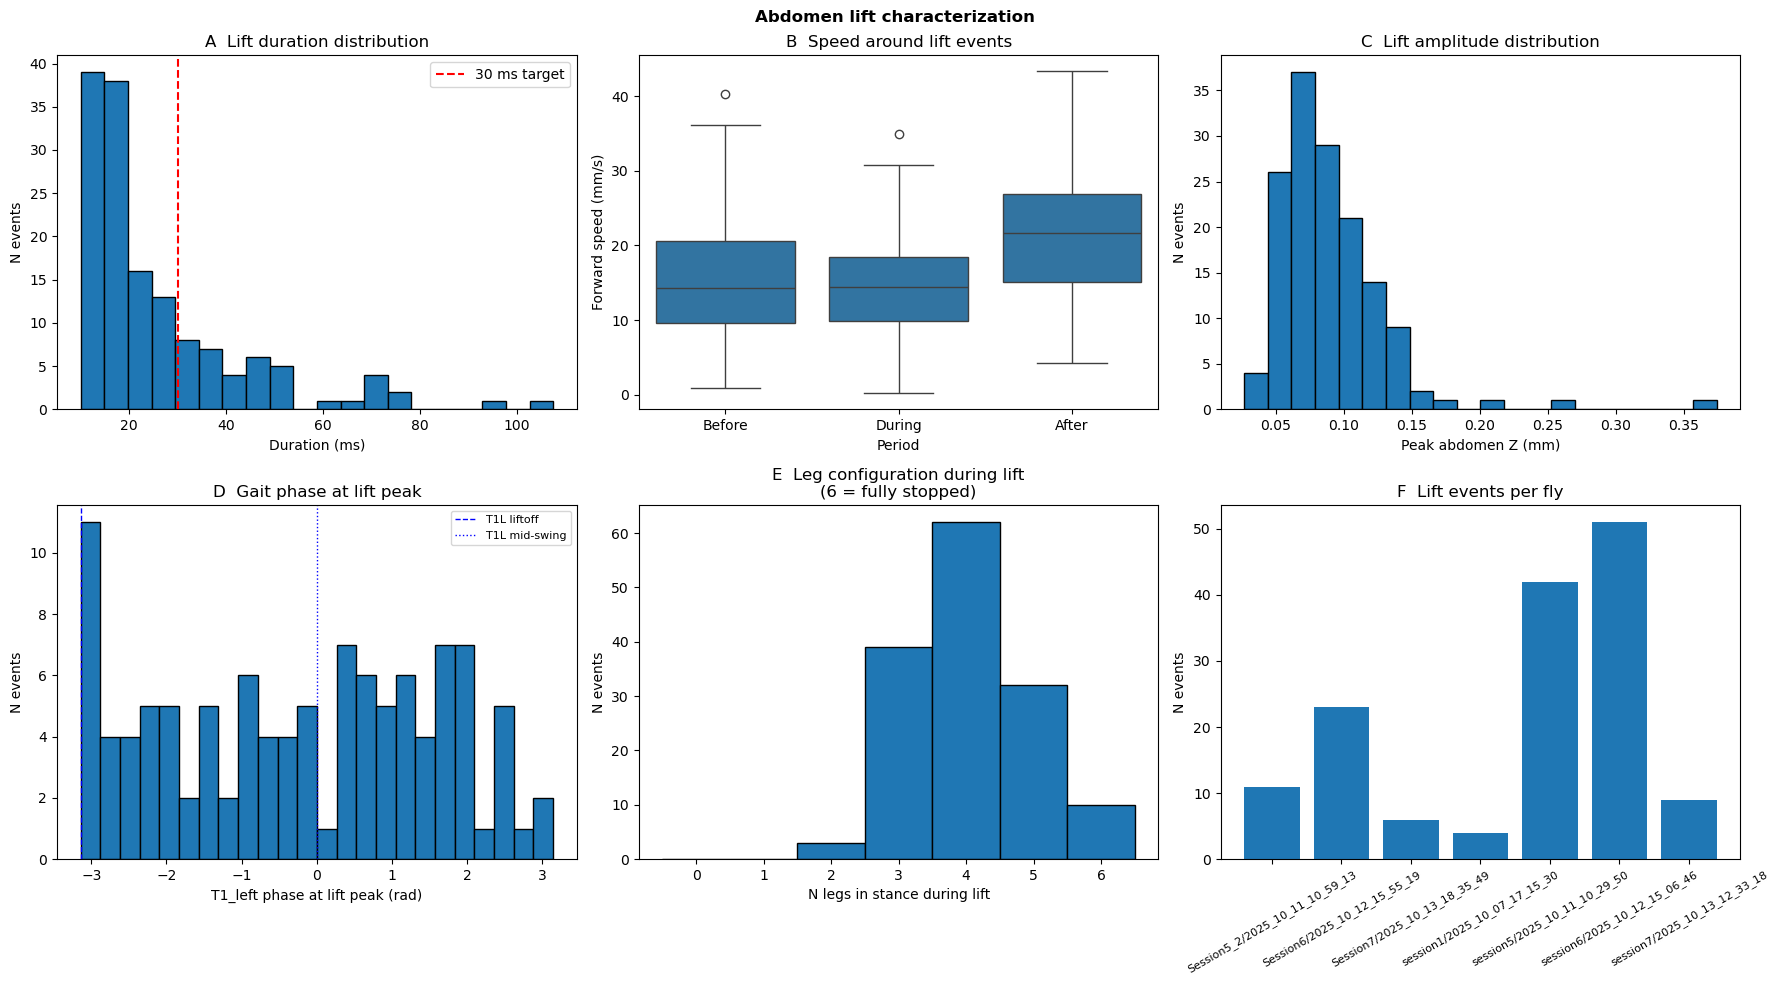

In [7]:
### Cell I5 — Characterize lift events (6-panel figure)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A: Duration distribution
axes[0, 0].hist(lift_df['duration_ms'], bins=20, edgecolor='k')
axes[0, 0].axvline(30, color='r', ls='--', label='30 ms target')
axes[0, 0].set_xlabel('Duration (ms)'); axes[0, 0].set_ylabel('N events')
axes[0, 0].set_title('A  Lift duration distribution')
axes[0, 0].legend()

# B: Speed before / during / after
_spd_df = pd.DataFrame({
    'Before': lift_df['mean_speed_before'],
    'During': lift_df['mean_speed_during'],
    'After':  lift_df['mean_speed_after'],
})
sns.boxplot(data=_spd_df.melt(var_name='Period', value_name='Speed'),
            x='Period', y='Speed', ax=axes[0, 1])
axes[0, 1].set_ylabel('Forward speed (mm/s)')
axes[0, 1].set_title('B  Speed around lift events')

# C: Peak amplitude
axes[0, 2].hist(lift_df['peak_abd_z_mm'], bins=20, edgecolor='k')
axes[0, 2].set_xlabel('Peak abdomen Z (mm)'); axes[0, 2].set_ylabel('N events')
axes[0, 2].set_title('C  Lift amplitude distribution')

# D: Gait phase at lift peak
_phases    = lift_df['T1L_phase_at_peak'].dropna().values
_phase_bins = np.linspace(-np.pi, np.pi, 25)
axes[1, 0].hist(_phases, bins=_phase_bins, edgecolor='k')
axes[1, 0].axvline(-np.pi, color='b', ls='--', lw=1, label='T1L liftoff')
axes[1, 0].axvline(0,      color='b', ls=':',  lw=1, label='T1L mid-swing')
axes[1, 0].set_xlabel('T1_left phase at lift peak (rad)')
axes[1, 0].set_ylabel('N events')
axes[1, 0].set_title('D  Gait phase at lift peak')
axes[1, 0].legend(fontsize=8)

# E: N legs in stance during lift
axes[1, 1].hist(lift_df['n_legs_stance_at_peak'].dropna().values,
                bins=np.arange(-0.5, 7.5, 1), edgecolor='k')
axes[1, 1].set_xlabel('N legs in stance during lift')
axes[1, 1].set_ylabel('N events')
axes[1, 1].set_title('E  Leg configuration during lift\n(6 = fully stopped)')
axes[1, 1].set_xticks(range(7))

# F: Events per fly
lift_per_fly = lift_df.groupby('fly_id').size().reset_index(name='n_events')
axes[1, 2].bar(range(len(lift_per_fly)), lift_per_fly['n_events'])
axes[1, 2].set_xticks(range(len(lift_per_fly)))
axes[1, 2].set_xticklabels(lift_per_fly['fly_id'], rotation=30, fontsize=8)
axes[1, 2].set_ylabel('N events')
axes[1, 2].set_title('F  Lift events per fly')

plt.suptitle('Abdomen lift characterization', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'abdomen_lift_characterization.pdf', bbox_inches='tight')
plt.show()

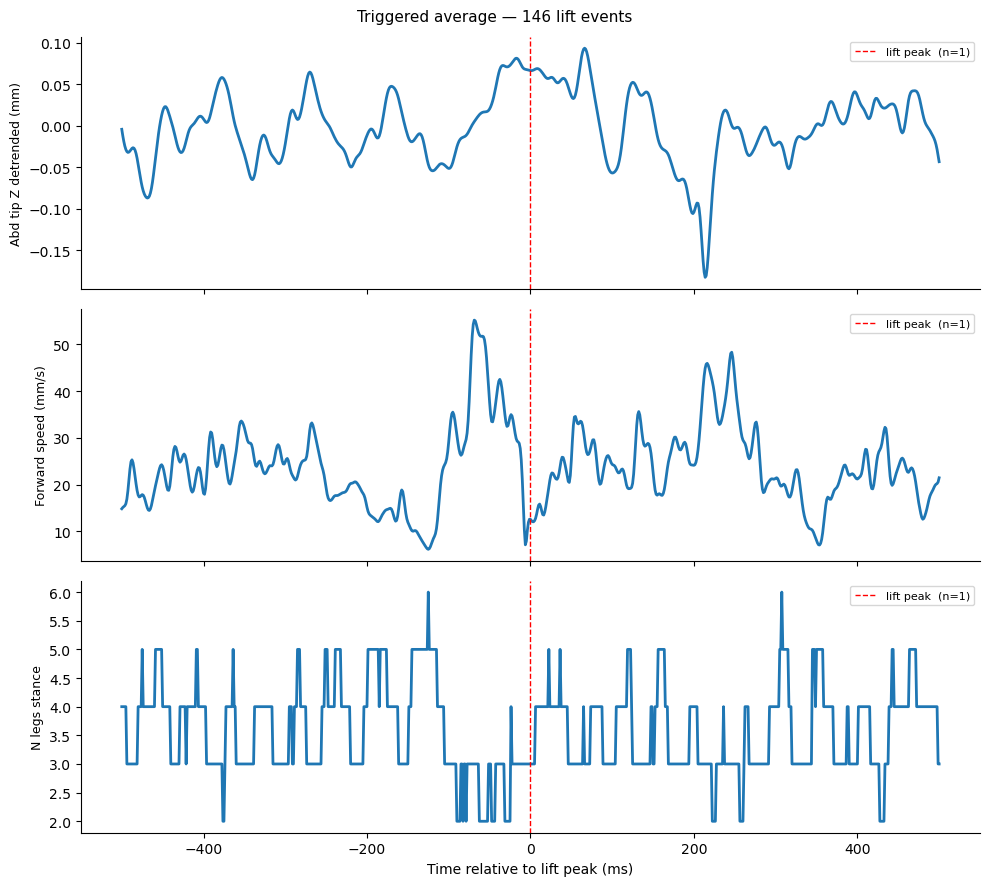

Good detector: sharp abd_z peak at t=0, flat thorax_z, n_legs_stance ≥ 5, speed dip near t=0.


In [8]:
### Cell I6 — Visual validation: triggered average around lift events

WINDOW_MS   = 500
WINDOW_HALF = int(WINDOW_MS / 1000 * FPS)

signals_to_avg = {
    'abd_tip_detrended_mm': 'Abd tip Z detrended (mm)',
    'forward_speed':        'Forward speed (mm/s)',
    'n_legs_stance':        'N legs stance',
    'thorax_z_detrended':   'Thorax Z detrended (mm)',
}
# thorax_z_detrended needs Cell H1 of Scutellum_Height_Running to have been run;
# if not available it will be skipped gracefully.

triggered = {k: [] for k in signals_to_avg}

for _, ev in lift_df.iterrows():
    bid  = ev['bout_id']
    peak = int(ev['bout_frame_start'] +
               (ev['bout_frame_end'] - ev['bout_frame_start']) // 2)
    grp  = df_valid[df_valid['bout_id'] == bid].sort_values('frame')
    grp_frames = grp['frame'].values
    peak_pos   = np.searchsorted(grp_frames, peak)
    t0 = peak_pos - WINDOW_HALF
    t1 = peak_pos + WINDOW_HALF + 1
    if t0 < 0 or t1 > len(grp):
        continue
    for sig in signals_to_avg:
        if sig in grp.columns:
            triggered[sig].append(grp[sig].values[t0:t1])

t_axis_ms = np.linspace(-WINDOW_MS, WINDOW_MS, 2 * WINDOW_HALF + 1)

available = {k: v for k, v in triggered.items() if v}
fig, axes = plt.subplots(len(available), 1, figsize=(10, 3 * len(available)), sharex=True)
if len(available) == 1: axes = [axes]

for ax, (sig, label) in zip(axes, {k: signals_to_avg[k] for k in available}.items()):
    arr        = np.array([a for a in available[sig] if len(a) == 2*WINDOW_HALF+1])
    mean_trace = np.nanmean(arr, axis=0)
    sem_trace  = np.nanstd(arr, axis=0) / np.sqrt(len(arr))
    ax.fill_between(t_axis_ms, mean_trace - sem_trace, mean_trace + sem_trace, alpha=0.3)
    ax.plot(t_axis_ms, mean_trace, lw=2)
    ax.axvline(0, color='r', ls='--', lw=1, label=f'lift peak  (n={len(arr)})')
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Time relative to lift peak (ms)')
plt.suptitle(f'Triggered average — {len(lift_df)} lift events', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'abdomen_lift_triggered_avg.pdf', bbox_inches='tight')
plt.show()

print("Good detector: sharp abd_z peak at t=0, flat thorax_z, n_legs_stance ≥ 5, speed dip near t=0.")

In [9]:
### Cell I7 — UMAP integration: overlay lift events as color variable

# Use is_abd_lift as a color variable in the existing UMAP embeddings.
# Requires umap_result_fly_norm from the UMAP analysis plan (Part B).
# If not available, prints a skip message.

if 'umap_result_fly_norm' not in dir():
    print("umap_result_fly_norm not found — run the UMAP notebook (Part B) first.")
    print("Cell I7 requires umap_result_fly_norm with shape (len(df_valid), 2).")
else:
    _is_lift = df_valid['is_abd_lift'].values.astype(float)

    if len(_is_lift) != len(umap_result_fly_norm):
        print(f"Shape mismatch: df_valid has {len(_is_lift)} rows but "
              f"umap_result_fly_norm has {len(umap_result_fly_norm)} rows.")
        print("Ensure both arrays index the same frame-level df_valid.")
    else:
        _n_lift_frames = int(_is_lift.sum())
        _n_total       = len(_is_lift)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # ── Panel A: lift vs. non-lift ────────────────────────────────────────
        axes[0].scatter(
            umap_result_fly_norm[_is_lift == 0, 0],
            umap_result_fly_norm[_is_lift == 0, 1],
            s=1, alpha=0.15, c='lightgray', rasterized=True,
            label=f'Non-lift  ({_n_total - _n_lift_frames:,} frames)',
        )
        axes[0].scatter(
            umap_result_fly_norm[_is_lift == 1, 0],
            umap_result_fly_norm[_is_lift == 1, 1],
            s=8, alpha=0.8, c='red', rasterized=True,
            label=f'Abd lift  ({_n_lift_frames:,} frames)',
        )
        axes[0].set_xlabel('UMAP 1')
        axes[0].set_ylabel('UMAP 2')
        axes[0].set_title('A  Abdomen lift events in UMAP space')
        axes[0].legend(fontsize=9, markerscale=4)
        axes[0].spines[['top', 'right']].set_visible(False)

        # ── Panel B: color by lift peak amplitude ─────────────────────────────
        # Map each frame to the amplitude of its associated lift event (0 if not a lift)
        _amp_col = np.zeros(len(df_valid))
        for _, ev in lift_df.iterrows():
            bid = ev['bout_id']
            t0  = ev['bout_frame_start']
            t1  = ev['bout_frame_end']
            mask = ((df_valid['bout_id'] == bid) &
                    (df_valid['frame'] >= t0) &
                    (df_valid['frame'] <= t1)).values
            _amp_col[mask] = float(ev['peak_abd_z_mm'])

        _lift_mask = _is_lift == 1
        sc = axes[1].scatter(
            umap_result_fly_norm[_lift_mask, 0],
            umap_result_fly_norm[_lift_mask, 1],
            s=8, alpha=0.8,
            c=_amp_col[_lift_mask],
            cmap='hot_r',
            vmin=np.percentile(_amp_col[_lift_mask], 5),
            vmax=np.percentile(_amp_col[_lift_mask], 95),
            rasterized=True,
        )
        # Gray background
        axes[1].scatter(
            umap_result_fly_norm[~_lift_mask, 0],
            umap_result_fly_norm[~_lift_mask, 1],
            s=1, alpha=0.05, c='lightgray', rasterized=True, zorder=0,
        )
        plt.colorbar(sc, ax=axes[1], label='Peak abd Z (mm)')
        axes[1].set_xlabel('UMAP 1')
        axes[1].set_ylabel('UMAP 2')
        axes[1].set_title('B  Lift amplitude in UMAP space')
        axes[1].spines[['top', 'right']].set_visible(False)

        plt.suptitle(f'Abdomen lift events in UMAP embedding\n'
                     f'{_n_lift_frames:,} lift frames = '
                     f'{_n_lift_frames/_n_total*100:.1f}% of all walking frames',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'umap_abdomen_lift_overlay.pdf', bbox_inches='tight')
        plt.show()

        print(f"Lift frames: {_n_lift_frames:,} / {_n_total:,} "
              f"({_n_lift_frames/_n_total*100:.2f}%)")
        print("If lift events cluster tightly in UMAP → detector is capturing "
              "a distinct behavioral state.")
        print("If scattered → lifts co-occur with other behaviors (running, "
              "grooming prep, turns).")

umap_result_fly_norm not found — run the UMAP notebook (Part B) first.
Cell I7 requires umap_result_fly_norm with shape (len(df_valid), 2).
